# Keith Wampler
# 569 Spring 2026
# Homework 3

The goal of this  homework is to build familiarity with PyTorch and also to practice tuning. Try this using PyTorch, but tensor flow is fine too. 

Change the data set to the cancer file (it's available "from sklearn.datasets import load_breast_cancer")

Write a script to tune a model’s hyperparameters

Test different numbers of hidden layers (1-4) with different widths (10-50 by 10)
Change the base learning rate by +/- 10%
Estimate the number of learned parameters involved with the model
 
Send me your code and a couple of paragraphs describing any patterns in the performance and also a couple of paragraphs describing any tradeoffs in model complexity and model performance

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import random

SEED = 1701

random.seed(SEED)
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

In [44]:
def prepare_data():
    data = load_breast_cancer()
    X = data.data
    y = data.target
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
    
    print(f"Training Tensor Shape: {X_train_t.shape}")
    print(f"Input Dimension (Features): {X_train_t.shape[1]}\n")
    
    return X_train_t, X_test_t, y_train_t, y_test_t

X_train, X_test, y_train, y_test = prepare_data()

Training Tensor Shape: torch.Size([455, 30])
Input Dimension (Features): 30



In [45]:
class DynamicNet(nn.Module):
    def __init__(self, input_size, num_hidden_layers, hidden_width):
        super(DynamicNet, self).__init__()
        
        layers = []
        current_dim = input_size
        
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(current_dim, hidden_width))
            layers.append(nn.ReLU())
            current_dim = hidden_width
            
        layers.append(nn.Linear(current_dim, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [46]:
def tune_hyperparameters(X_train, X_test, y_train, y_test):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    input_size = X_train.shape[1]
    
    hidden_layers_grid = [1, 2, 3, 4]
    widths_grid = [10, 20, 30, 40, 50]
    
    base_lr = 0.01
    learning_rates = [base_lr * 0.9, base_lr, base_lr * 1.1]
    
    epochs = 100
    results = []
        
    best_acc_per_lr = {lr: 0 for lr in learning_rates}
    loss_histories_per_lr = {lr: [] for lr in learning_rates}

    print(f"{'Layers':<8} | {'Width':<7} | {'LR':<7} | {'Params':<8} | {'Test Acc':<8}")
    print("-" * 50)
    
    for layers, width, lr in itertools.product(hidden_layers_grid, widths_grid, learning_rates):
        
        model = DynamicNet(input_size=input_size, num_hidden_layers=layers, hidden_width=width)
        num_params = count_parameters(model)
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        current_loss_history = []
        
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
            
            current_loss_history.append(loss.item())
            
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            predictions = torch.round(torch.sigmoid(test_outputs))
            correct = (predictions == y_test).sum().item()
            accuracy = correct / y_test.size(0)
            
        if accuracy > best_acc_per_lr[lr]:
            best_acc_per_lr[lr] = accuracy
            loss_histories_per_lr[lr] = current_loss_history
            
        results.append({
            'layers': layers,
            'width': width,
            'lr': lr,
            'params': num_params,
            'accuracy': accuracy
        })
        
        print(f"{layers:<8} | {width:<7} | {lr:.4f} | {num_params:<8} | {accuracy*100:.2f}%")

    return pd.DataFrame(results), loss_histories_per_lr


results_df, loss_histories_per_lr = tune_hyperparameters(X_train, X_test, y_train, y_test)

Layers   | Width   | LR      | Params   | Test Acc
--------------------------------------------------
1        | 10      | 0.0090 | 321      | 98.25%
1        | 10      | 0.0100 | 321      | 97.37%
1        | 10      | 0.0110 | 321      | 98.25%
1        | 20      | 0.0090 | 641      | 97.37%
1        | 20      | 0.0100 | 641      | 97.37%
1        | 20      | 0.0110 | 641      | 98.25%
1        | 30      | 0.0090 | 961      | 98.25%
1        | 30      | 0.0100 | 961      | 97.37%
1        | 30      | 0.0110 | 961      | 96.49%
1        | 40      | 0.0090 | 1281     | 97.37%
1        | 40      | 0.0100 | 1281     | 96.49%
1        | 40      | 0.0110 | 1281     | 98.25%
1        | 50      | 0.0090 | 1601     | 98.25%
1        | 50      | 0.0100 | 1601     | 97.37%
1        | 50      | 0.0110 | 1601     | 97.37%
2        | 10      | 0.0090 | 431      | 99.12%
2        | 10      | 0.0100 | 431      | 97.37%
2        | 10      | 0.0110 | 431      | 98.25%
2        | 20      | 0.0090 | 1061

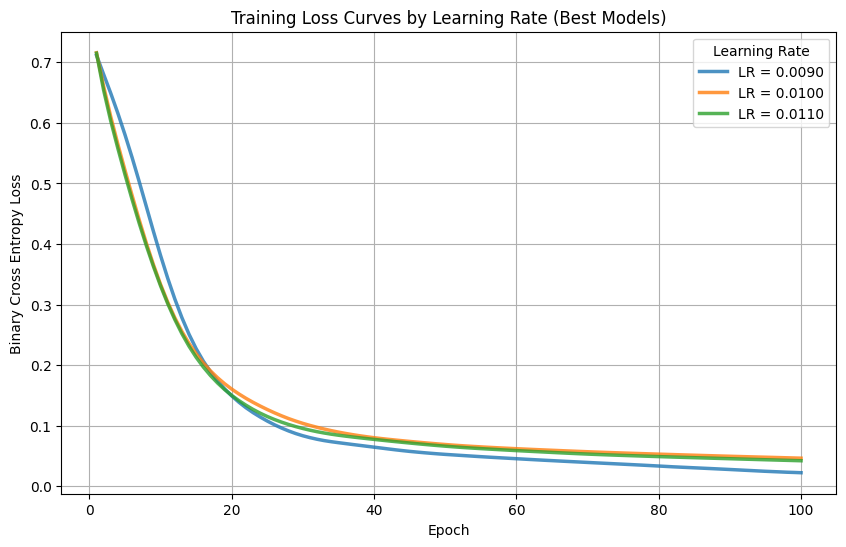

In [47]:
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for (lr, history), color in zip(loss_histories_per_lr.items(), colors):
    plt.plot(
        range(1, len(history) + 1), 
        history, 
        color=color, 
        linewidth=2.5, 
        alpha=0.8,
        label=f'LR = {lr:.4f}'
    )

plt.title('Training Loss Curves by Learning Rate (Best Models)')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend(title='Learning Rate')
plt.grid(True)
plt.show()

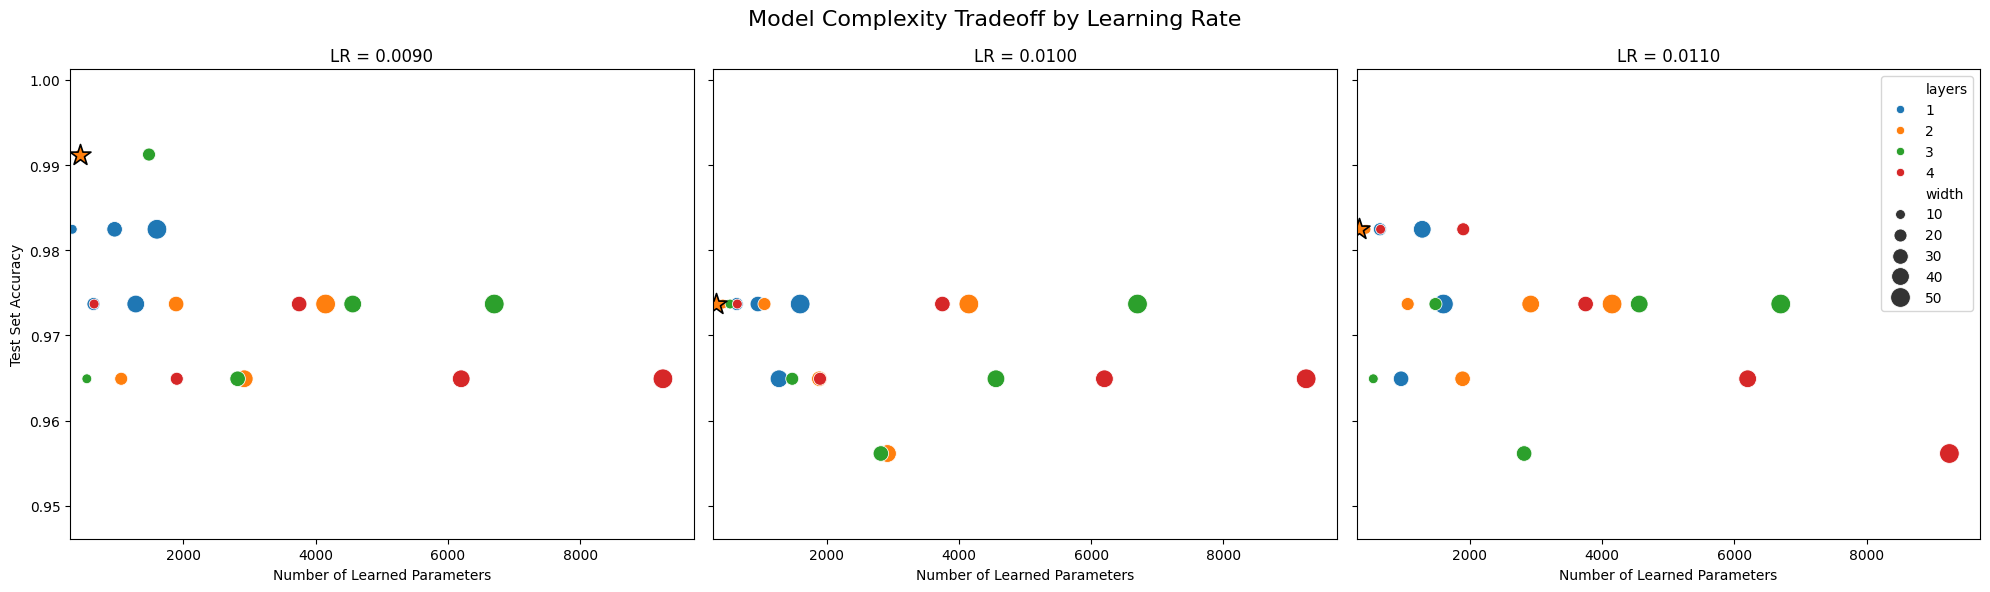

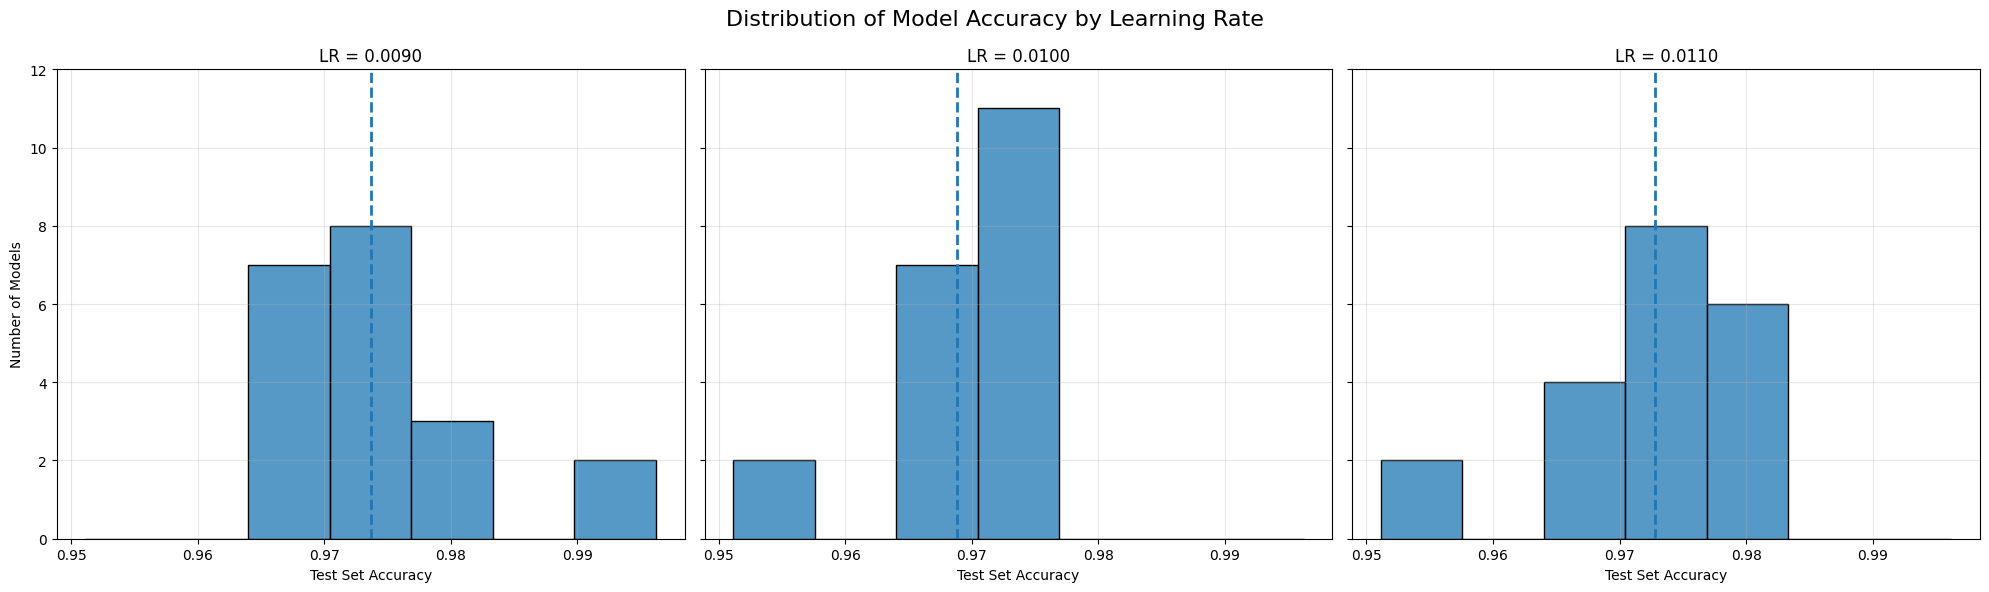

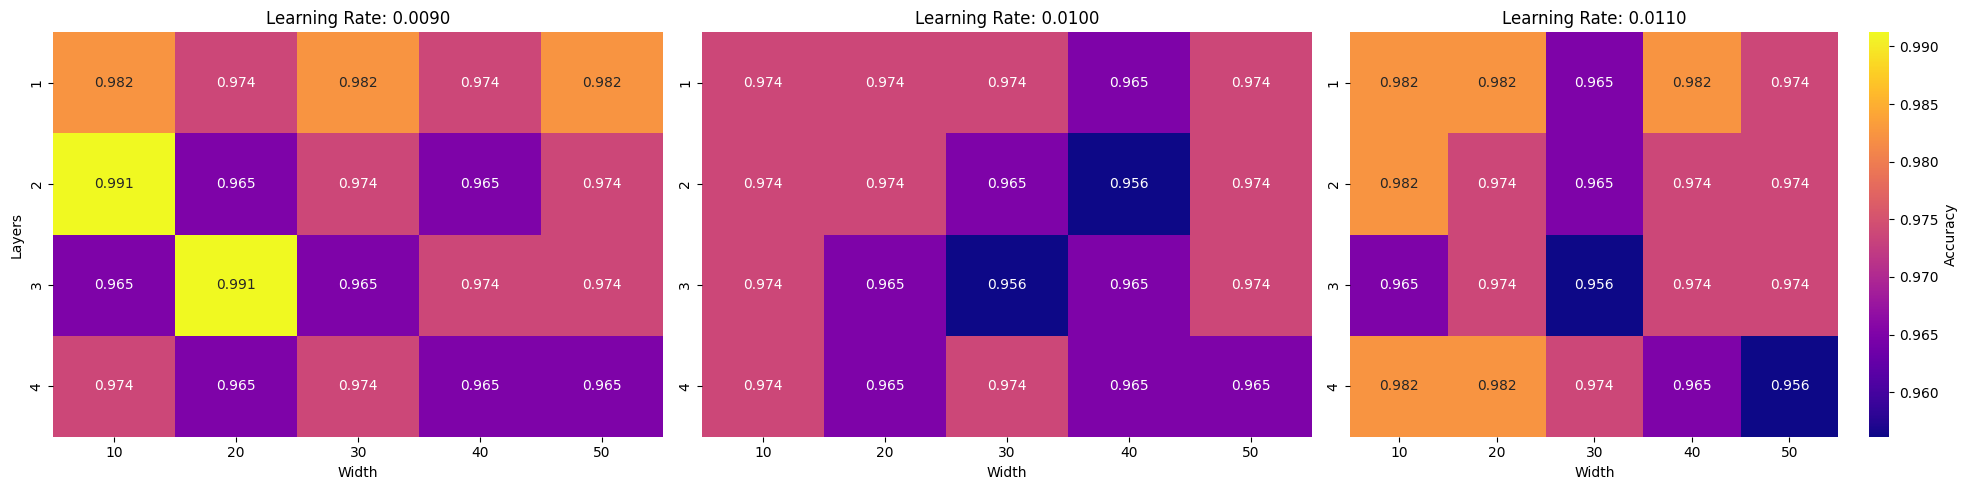

In [48]:
learning_rates = sorted(results_df['lr'].unique())

x_min = results_df['params'].min() * 0.9
x_max = results_df['params'].max() * 1.05
y_min = results_df['accuracy'].min() - 0.01
y_max = results_df['accuracy'].max() + 0.01

fig, axes = plt.subplots(1, len(learning_rates), figsize=(20, 6), sharex=True, sharey=True)

for i, lr in enumerate(learning_rates):
    subset = results_df[np.isclose(results_df['lr'], lr)]
    
    sns.scatterplot(
    data=subset,
    x='params',
    y='accuracy',
    hue='layers',
    size='width',
    palette='tab10',
    sizes=(50, 200),
    ax=axes[i],
    legend=(i == len(learning_rates) - 1)
)
    
    best = subset.loc[subset['accuracy'].idxmax()]
    
    axes[i].scatter(
        best['params'],
        best['accuracy'],
        s=250,
        marker='*',
        edgecolor='black',
        linewidth=1.2
    )
    
    axes[i].set_title(f"LR = {lr:.4f}")
    axes[i].set_xlabel("Number of Learned Parameters")
    axes[i].set_ylabel("Test Set Accuracy")
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    
fig.suptitle("Model Complexity Tradeoff by Learning Rate", fontsize=16)
plt.tight_layout()
plt.show()

learning_rates = sorted(results_df['lr'].unique())

bins = np.linspace(
    results_df['accuracy'].min() - 0.005,
    results_df['accuracy'].max() + 0.005,
    8
)

y_max = 0

# First pass to find shared y-axis maximum
for lr in learning_rates:
    subset = results_df[np.isclose(results_df['lr'], lr)]
    counts, _ = np.histogram(subset['accuracy'], bins=bins)
    y_max = max(y_max, counts.max())

fig, axes = plt.subplots(1, len(learning_rates), figsize=(20, 6), sharex=True, sharey=True)

for i, lr in enumerate(learning_rates):
    subset = results_df[np.isclose(results_df['lr'], lr)]
    
    sns.histplot(
        data=subset,
        x='accuracy',
        bins=bins,
        ax=axes[i]
    )
    
    mean_accuracy = subset['accuracy'].mean()
    axes[i].axvline(mean_accuracy, linestyle='--', linewidth=2)
    
    axes[i].set_title(f"LR = {lr:.4f}")
    axes[i].set_xlabel("Test Set Accuracy")
    axes[i].set_ylabel("Number of Models")
    axes[i].set_ylim(0, y_max + 1)
    axes[i].grid(True, alpha=0.3)

fig.suptitle("Distribution of Model Accuracy by Learning Rate", fontsize=16)
plt.tight_layout()
plt.show()

learning_rates = sorted(results_df['lr'].unique())
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
vmin, vmax = results_df['accuracy'].min(), results_df['accuracy'].max()

for i, lr in enumerate(learning_rates):
    subset = results_df[abs(results_df['lr'] - lr) < 1e-6]
    pivot = subset.pivot(index='layers', columns='width', values='accuracy')
    
    sns.heatmap(
        pivot, 
        annot=True, 
        fmt=".3f",
        xticklabels=True, 
        yticklabels=True, 
        cmap="plasma", 
        vmin=vmin, 
        vmax=vmax, 
        ax=axes[i], 
        cbar=(i == 2),
        cbar_kws={'label': 'Accuracy'} if i == 2 else {}
    )
    axes[i].set_title(f'Learning Rate: {lr:.4f}')
    axes[i].set_xlabel('Width')
    axes[i].set_ylabel('Layers' if i == 0 else '')

plt.tight_layout()
plt.show()



In [49]:
print("Model Stats")
print("-----------")

TEST_N = len(y_test)              
df = results_df.copy()
df["acc_pct"] = df["accuracy"] * 100

def section(title):
    print("\n" + title)
    print("-" * len(title))

section("Overall performance")
print(f"Configurations evaluated : {len(df)}")
print(f"Accuracy min / max       : {df.acc_pct.min():.2f}% / {df.acc_pct.max():.2f}%")
print(f"Accuracy mean +/- std    : {df.acc_pct.mean():.2f}% +/- {df.acc_pct.std():.2f}%")
print(f"Test set size            : {TEST_N} samples")
print(f"Value of one sample      : {100 / TEST_N:.2f}%")
print(f"Distinct accuracy values mapped to correct-count out of {TEST_N}:")
for a in sorted(df.acc_pct.unique()):
    k = round(a / 100 * TEST_N)
    n = int((df.acc_pct == a).sum())
    print(f"    {a:6.2f}%  =  {k}/{TEST_N}   ({n} configs)")

section("Learning rate effect")
lr_means = df.groupby("lr")["acc_pct"].agg(["mean", "min", "max", "count"])
print(lr_means.round(3).to_string())
spread = lr_means["mean"].max() - lr_means["mean"].min()
print(f"Spread of per-rate means : {spread:.3f}%  ({spread / (100 / TEST_N):.2f} test samples)")
top = df[df.acc_pct == df.acc_pct.max()]
peak_lrs = ", ".join(f"{v:.3f}" for v in sorted(top.lr.unique()))
print(f"Configs at peak accuracy : {len(top)}, all at LR = {peak_lrs}")

section("Complexity vs accuracy")
print(f"Parameter count range    : {df.params.min()} to {df.params.max()} "
      f"({df.params.max() / df.params.min():.1f}-fold)")
print(f"Pearson r, params vs acc : {df['params'].corr(df.acc_pct):+.4f}")
print(f"Pearson r, layers vs acc : {df['layers'].corr(df.acc_pct):+.4f}")
print(f"Pearson r, width  vs acc : {df['width'].corr(df.acc_pct):+.4f}")
print("Mean accuracy by depth:")
print(df.groupby("layers")["acc_pct"].mean().round(3).to_string())
print("Mean accuracy by width:")
print(df.groupby("width")["acc_pct"].mean().round(3).to_string())

section("Best practical model")
top_sorted = top.sort_values("params")
for _, r in top_sorted.iterrows():
    print(f"    {int(r.layers)} layers, width {int(r.width)}, LR {r.lr:.3f}  ->  "
          f"{r.acc_pct:.2f}%  with {int(r.params)} params")
smallest, largest = top_sorted.iloc[0], top_sorted.iloc[-1]
print(f"Param ratio small/large  : {smallest['params'] / largest['params']:.3f} ")

df = results_df.copy()
df["acc_pct"] = df["accuracy"] * 100


p_min = df[df.layers == 1]["params"].min()
p_max = df[df.layers == 4]["params"].max()
print(f"smallest single-layer network, params  : {p_min}")
print(f"largest four-layer network, params     : {p_max}")
print(f"fold increase in capacity              : {p_max / p_min:.1f}x")
print()
print("Pearson r (linear association):")
print(f"  params vs accuracy : {df['params'].corr(df['acc_pct']):+.3f}")
print(f"  layers vs accuracy : {df['layers'].corr(df['acc_pct']):+.3f}")
print(f"  width  vs accuracy : {df['width'].corr(df['acc_pct']):+.3f}")
print("Spearman rho (rank-based, robust to nonlinearity and outliers):")
print(f"  params vs accuracy : {df['params'].corr(df['acc_pct'], method='spearman'):+.3f}")
print(f"  layers vs accuracy : {df['layers'].corr(df['acc_pct'], method='spearman'):+.3f}")
print(f"  width  vs accuracy : {df['width'].corr(df['acc_pct'], method='spearman'):+.3f}")
print()
print("Mean accuracy by hidden-layer depth:")
print(df.groupby("layers")["acc_pct"].mean().round(2).to_string())
print()
print("Mean accuracy by hidden-layer width:")
print(df.groupby("width")["acc_pct"].mean().round(2).to_string())

print()

top = df[df["acc_pct"] == df["acc_pct"].max()].sort_values("params")
for _, r in top.iterrows():
    print(f"  {int(r.layers)}-layer, width {int(r.width)}, LR = {r.lr:.3f}  ->  "
          f"{r.acc_pct:.2f}% with {int(r.params)} params")
ratio = top.iloc[0]["params"] / top.iloc[-1]["params"]
print(f"smaller-to-larger param ratio (top two)  : {ratio:.3f}  ({ratio*100:.1f}%)")

Model Stats
-----------

Overall performance
-------------------
Configurations evaluated : 60
Accuracy min / max       : 95.61% / 99.12%
Accuracy mean +/- std    : 97.18% +/- 0.79%
Test set size            : 114 samples
Value of one sample      : 0.88%
Distinct accuracy values mapped to correct-count out of 114:
     95.61%  =  109/114   (4 configs)
     96.49%  =  110/114   (18 configs)
     97.37%  =  111/114   (27 configs)
     98.25%  =  112/114   (9 configs)
     99.12%  =  113/114   (2 configs)

Learning rate effect
--------------------
         mean     min     max  count
lr                                  
0.009  97.368  96.491  99.123     20
0.010  96.886  95.614  97.368     20
0.011  97.281  95.614  98.246     20
Spread of per-rate means : 0.482%  (0.55 test samples)
Configs at peak accuracy : 2, all at LR = 0.009

Complexity vs accuracy
----------------------
Parameter count range    : 321 to 9251 (28.8-fold)
Pearson r, params vs acc : -0.3906
Pearson r, layers vs acc : -0

## Patterns in the Performance

Test accuracy across all 60 configurations stayed between 95.6% and 99.1%, with most models landing at 96.5% or 97.4%. The breast cancer dataset is small and close to linearly separable after standardization, so even the smallest network captured most of the available signal. With only 114 test samples, one prediction is worth about 0.9% of accuracy, so the full spread across the grid amounts to four samples flipping correct or incorrect.

Adjusting the base learning rate by plus or minus 10% did not change much. Mean accuracy was 97.4% at LR = 0.009, 96.9% at LR = 0.010, and 97.3% at LR = 0.011. The training loss curves for the best model at each rate converged smoothly with no instability, which suggests that all three rates are workable. Both runs that reached 99.1% happened to use LR = 0.009, but the per-rate means are too close together to call one rate clearly better than another.

## Tradeoffs in Model Complexity and Model Performance

Parameter counts ranged from 321 in the smallest single-layer network to 9,251 in the largest four-layer network, a roughly 29-fold range. Larger models did not perform better. Mean accuracy held near 97% across all depths and widths, with a slight downward drift as size grew. On a problem of this scale, the extra capacity had little to act on.

The most efficient model was the two-layer, width-10 network at LR = 0.009, which reached 99.1% with 431 parameters. The only other model to match it was a three-layer, width-20 network with 1,481 parameters, more than three times the size. For a dataset this small, the smaller network is the better practical choice because it reaches the same test accuracy with lower computational cost and less unnecessary model complexity.